https://www.learnpytorch.io/

https://github.com/mrdbourke/pytorch-deep-learning

## **Todos**

* Sigmoid
* Softmax

# PyTorch Neural Network Classification

<img src="https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/images/02-different-classification-problems.png" width=680>

https://www.learnpytorch.io/02_pytorch_classification/

<div class="md-typeset__table"><table>
<thead>
<tr>
<th><strong>Hyperparameter</strong></th>
<th><strong>Binary Classification</strong></th>
<th><strong>Multiclass classification</strong></th>
</tr>
</thead>
<tbody>
<tr>
<td><strong>Input layer shape</strong> (<code>in_features</code>)</td>
<td>Same as number of features (e.g. 5 for age, sex, height, weight, smoking status in heart disease prediction)</td>
<td>Same as binary classification</td>
</tr>
<tr>
<td><strong>Hidden layer(s)</strong></td>
<td>Problem specific, minimum = 1, maximum = unlimited</td>
<td>Same as binary classification</td>
</tr>
<tr>
<td><strong>Neurons per hidden layer</strong></td>
<td>Problem specific, generally 10 to 512</td>
<td>Same as binary classification</td>
</tr>
<tr>
<td><strong>Output layer shape</strong> (<code>out_features</code>)</td>
<td>1 (one class or the other)</td>
<td>1 per class (e.g. 3 for food, person or dog photo)</td>
</tr>
<tr>
<td><strong>Hidden layer activation</strong></td>
<td>Usually <a href="https://pytorch.org/docs/stable/generated/torch.nn.ReLU.html#torch.nn.ReLU">ReLU</a> (rectified linear unit) but <a href="https://en.wikipedia.org/wiki/Activation_function#Table_of_activation_functions">can be many others</a></td>
<td>Same as binary classification</td>
</tr>
<tr>
<td><strong>Output activation</strong></td>
<td><a href="https://en.wikipedia.org/wiki/Sigmoid_function">Sigmoid</a> (<a href="https://pytorch.org/docs/stable/generated/torch.sigmoid.html"><code>torch.sigmoid</code></a> in PyTorch)</td>
<td><a href="https://en.wikipedia.org/wiki/Softmax_function">Softmax</a> (<a href="https://pytorch.org/docs/stable/generated/torch.nn.Softmax.html"><code>torch.softmax</code></a> in PyTorch)</td>
</tr>
<tr>
<td><strong>Loss function</strong></td>
<td><a href="https://en.wikipedia.org/wiki/Cross_entropy#Cross-entropy_loss_function_and_logistic_regression">Binary crossentropy</a> (<a href="https://pytorch.org/docs/stable/generated/torch.nn.BCELoss.html"><code>torch.nn.BCELoss</code></a> in PyTorch)</td>
<td>Cross entropy (<a href="https://pytorch.org/docs/stable/generated/torch.nn.CrossEntropyLoss.html"><code>torch.nn.CrossEntropyLoss</code></a> in PyTorch)</td>
</tr>
<tr>
<td><strong>Optimizer</strong></td>
<td><a href="https://pytorch.org/docs/stable/generated/torch.optim.SGD.html">SGD</a> (stochastic gradient descent), <a href="https://pytorch.org/docs/stable/generated/torch.optim.Adam.html">Adam</a> (see <a href="https://pytorch.org/docs/stable/optim.html"><code>torch.optim</code></a> for more options)</td>
<td>Same as binary classification</td>
</tr>
</tbody>
</table></div>

## **Import**

In [170]:
import torch
from torch import nn

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.datasets import load_breast_cancer, make_circles, make_blobs
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

torch.__version__

'2.6.0+cu124'

It contains a helpful function called plot_decision_boundary() which creates a NumPy meshgrid to **visually plot** the different points where our model is predicting certain classes.

In [171]:
import requests
from pathlib import Path

# Download helper functions from Learn PyTorch repo (if not already downloaded)
if Path("helper_functions.py").is_file():
  print("helper_functions.py already exists, skipping download")
else:
  print("Downloading helper_functions.py")
  request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py")
  with open("helper_functions.py", "wb") as f:
    f.write(request.content)

from helper_functions import plot_predictions, plot_decision_boundary

helper_functions.py already exists, skipping download


## **Constants**

In [172]:
RANDOM_SEED = 42

## **Device Agnostic**

In [173]:
if torch.cuda.is_available():
  device = "cuda"
elif torch.mps.is_available():
  device = "mps"
else:
  device = "cpu"

device

'cpu'

# *Breast Cancer*

Numerical Data

Binary Classification

## **Load Data**

https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic

In [174]:
input_data , target_data = load_breast_cancer(return_X_y=True, as_frame=True)

In [175]:
data = load_breast_cancer()
print(data.target_names)  # ['malignant' 'benign']
print(set(data.target))   # {0, 1}

['malignant' 'benign']
{np.int64(0), np.int64(1)}


In [176]:
input_data.head(2)

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.8,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.6,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.9,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.8,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902


In [177]:
target_data.value_counts()

,count
target,
1,357
0,212


In [178]:
data = input_data.copy()
data["target"] = target_data.copy()
data.nunique()

,0
mean radius,456
mean texture,479
mean perimeter,522
mean area,539
mean smoothness,474
mean compactness,537
mean concavity,537
mean concave points,542
mean symmetry,432
mean fractal dimension,499


## **Visualize**

### Correlations

<Axes: >

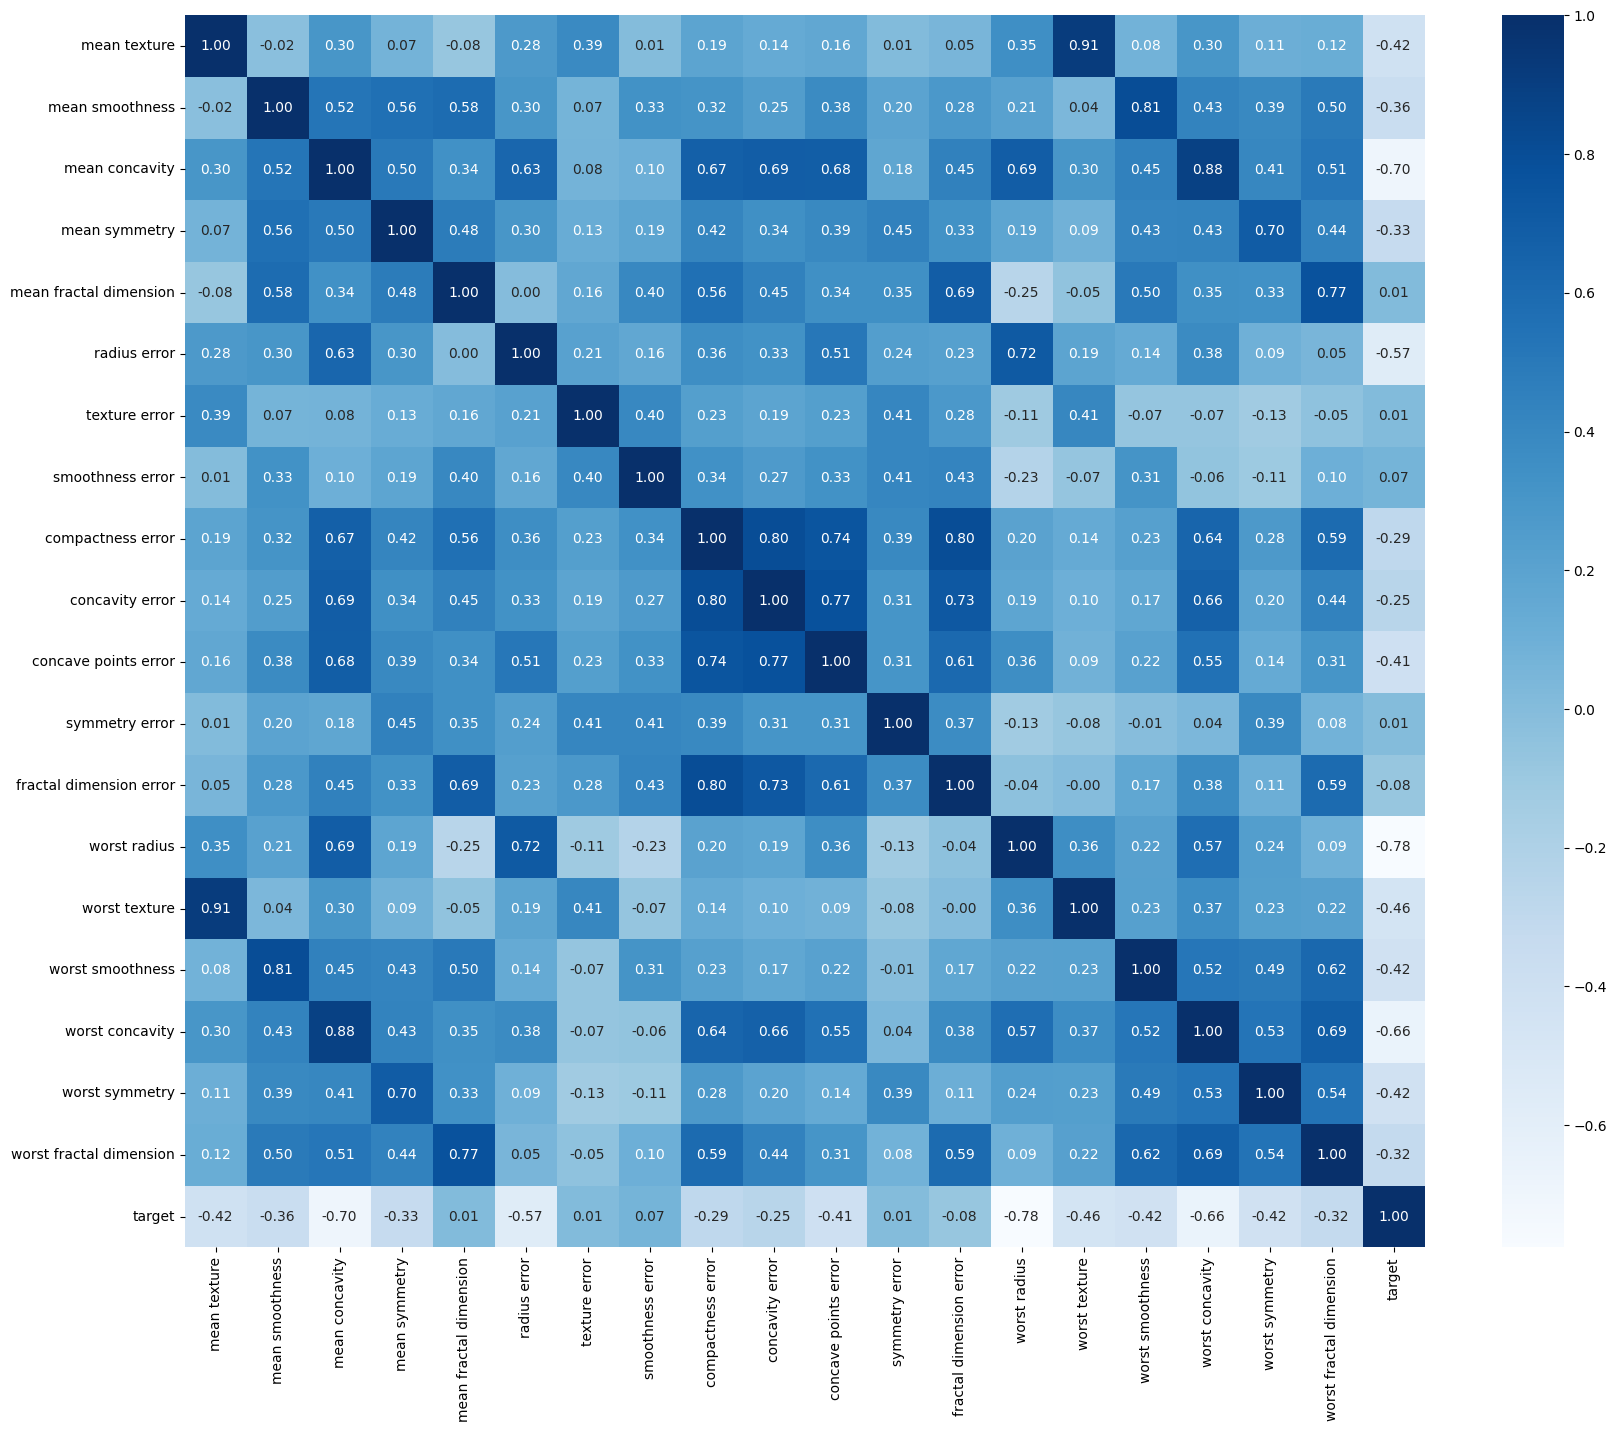

In [179]:
drop = ["mean compactness", "mean concave points", "mean radius", "mean perimeter", "perimeter error", "area error", "worst perimeter", "worst area", "worst compactness", "worst concave points", "mean area"]

fig, ax = plt.subplots(figsize=(20, 16))
sns.heatmap(data=data.drop(drop, axis=1).corr(), annot=True, cmap="Blues", fmt=".2f", ax=ax)

## **Input and Output**

### Type A
Features with high correlation are removed

In [180]:
drop = ["mean compactness", "mean concave points", "mean radius", "mean perimeter", "perimeter error",
        "area error", "worst perimeter", "worst area", "worst compactness", "worst concave points", "mean area"]

target = ["target"]

inputs_labels = [col for col in data.columns if col not in drop + target]

In [181]:
inputs_labels

['mean texture',
 'mean smoothness',
 'mean concavity',
 'mean symmetry',
 'mean fractal dimension',
 'radius error',
 'texture error',
 'smoothness error',
 'compactness error',
 'concavity error',
 'concave points error',
 'symmetry error',
 'fractal dimension error',
 'worst radius',
 'worst texture',
 'worst smoothness',
 'worst concavity',
 'worst symmetry',
 'worst fractal dimension']

## **Split Data**

In [182]:
X_train, X_test, y_train, y_test = train_test_split(input_data[inputs_labels], target_data, test_size=0.2, random_state=RANDOM_SEED)

In [183]:
X_train.shape, y_train.shape

((455, 19), (455,))

In [184]:
X_test.shape, y_test.shape

((114, 19), (114,))

## **Normalization**

In [185]:
scalar_model = StandardScaler()

X_train = scalar_model.fit_transform(X_train)
X_test = scalar_model.transform(X_test)

## **Convert Input and Output to Tensors**

* torch.from_numpy avoids copying the data (more efficient).

>>⚠️ But the returned tensor shares memory with the NumPy array — so if you modify one, it may affect the other.

* torch.tensor create a copy

In [186]:
# If X_train and X_test are already NumPy arrays
X_train = torch.from_numpy(X_train).float()
X_test = torch.from_numpy(X_test).float()

# If y_train and y_test are pandas Series or DataFrame, convert to NumPy first
y_train = torch.from_numpy(y_train.to_numpy()).float().unsqueeze(1)
y_test = torch.from_numpy(y_test.to_numpy()).float().unsqueeze(1)

## **Set Device**

In [187]:
X_train = X_train.to(device)
X_test = X_test.to(device)
y_train = y_train.to(device)
y_test = y_test.to(device)

## **Build a Model**

Class base for complex NNs

### NN Sequential

`nn.Sequential` is good for quick, simple model

nn.Sequential is fantastic for straight-forward computations, however, as the namespace says, it always runs in sequential order.

So if you'd like something else to happen (rather than just straight-forward sequential computation) you'll want to define your own custom nn.Module subclass.

In [188]:
# torch.manual_seed(RANDOM_SEED)
# torch.cuda.manual_seed(RANDOM_SEED)
# torch.mps.manual_seed(RANDOM_SEED)

# cancer_model_seq = nn.Sequential(
#         nn.Linear(in_features=19, out_features=32),
#         nn.Linear(in_features=32, out_features=1),
#     ).to(device)

### Class Based

In [189]:
class CancerModelV0(nn.Module):
  def __init__(self, input_size, output_size):
    super().__init__()

    self.layer0 = nn.Linear(in_features=input_size, out_features=32) # takes in 19 features (X), produces 32 features
    self.layer1 = nn.Linear(in_features=32, out_features=output_size) # takes in 32 features (X), produces 1 features (same shape as y)

  def forward(self, X: torch.tensor) -> torch.tensor:
    # computation goes through layer_1 first then the output of layer_1 goes through layer_2
    x = self.layer0(X)
    x = self.layer1(x)

    return x

In [190]:
torch.manual_seed(RANDOM_SEED)
torch.cuda.manual_seed(RANDOM_SEED)
torch.mps.manual_seed(RANDOM_SEED)

cancer_model = CancerModelV0(len(X_train[0]), len(y_train[0])).to(device)

In [191]:
cancer_model, next(cancer_model.parameters()).device

(CancerModelV0(
   (layer0): Linear(in_features=19, out_features=32, bias=True)
   (layer1): Linear(in_features=32, out_features=1, bias=True)
 ),
 device(type='cpu'))

#### Predictions

In [192]:
with torch.inference_mode():
  y_preds = cancer_model(X_test)

In [193]:
y_preds[:10]

tensor([[0.3192],
        [0.1788],
        [0.3987],
        [0.3379],
        [0.3716],
        [0.1749],
        [0.4675],
        [0.3528],
        [0.3117],
        [0.2503]])

## **Setup loss function and optimizer**

For a binary classification problem, you'll often use binary cross entropy as the loss function.

<div class="md-typeset__table"><table>
<thead>
<tr>
<th>Loss function/Optimizer</th>
<th>Problem type</th>
<th>PyTorch Code</th>
</tr>
</thead>
<tbody>
<tr>
<td>Stochastic Gradient Descent (SGD) optimizer</td>
<td>Classification, regression, many others.</td>
<td><a href="https://pytorch.org/docs/stable/generated/torch.optim.SGD.html"><code>torch.optim.SGD()</code></a></td>
</tr>
<tr>
<td>Adam Optimizer</td>
<td>Classification, regression, many others.</td>
<td><a href="https://pytorch.org/docs/stable/generated/torch.optim.Adam.html"><code>torch.optim.Adam()</code></a></td>
</tr>
<tr>
<td>Binary cross entropy loss</td>
<td>Binary classification</td>
<td><a href="https://pytorch.org/docs/stable/generated/torch.nn.BCEWithLogitsLoss.html"><code>torch.nn.BCELossWithLogits</code></a> or <a href="https://pytorch.org/docs/stable/generated/torch.nn.BCELoss.html"><code>torch.nn.BCELoss</code></a></td>
</tr>
<tr>
<td>Cross entropy loss</td>
<td>Multi-class classification</td>
<td><a href="https://pytorch.org/docs/stable/generated/torch.nn.CrossEntropyLoss.html"><code>torch.nn.CrossEntropyLoss</code></a></td>
</tr>
<tr>
<td>Mean absolute error (MAE) or L1 Loss</td>
<td>Regression</td>
<td><a href="https://pytorch.org/docs/stable/generated/torch.nn.L1Loss.html"><code>torch.nn.L1Loss</code></a></td>
</tr>
<tr>
<td>Mean squared error (MSE) or L2 Loss</td>
<td>Regression</td>
<td><a href="https://pytorch.org/docs/stable/generated/torch.nn.MSELoss.html#torch.nn.MSELoss"><code>torch.nn.MSELoss</code></a></td>
</tr>
</tbody>
</table></div>

In [194]:
# Create a loss function
# loss_fn = nn.BCELoss() # BCELoss = no sigmoid built-in
loss_fn = nn.BCEWithLogitsLoss() # BCEWithLogitsLoss = sigmoid built-in

# Create an optimizer
optimizer = torch.optim.SGD(params=cancer_model.parameters(), lr=0.01)

## **Train Model**

Our model outputs are going to be **raw logits**.

We can convert these **logits** into **prediction probabilities** by passing them to some kind of activation function (e.g. sigmoid for binary classification and softmax for multiclass classification).

Then we can convert our model's prediction probabilities to **prediction labels** by either rounding them or taking the argmax().

In [195]:
%%time
epochs = 1_001
logs = []

for epoch in range(epochs):
  ### Training
  cancer_model.train()

  # 1. Forward pass
  y_logits = cancer_model(X_train)

  # 2. Calculate loss/accuracy
  # loss = loss_fn(torch.sigmoid(y_logits), # nn.BCELoss expects prediction probabilities as input
  loss = loss_fn(y_logits, y_train)

  # 3. Optimizer zero grad
  optimizer.zero_grad()

  # 4. Loss backward (backpropagation)
  loss.backward()

  # 5. Optimizer step (gradient descent)
  optimizer.step()

  ### Testing
  cancer_model.eval()

  with torch.inference_mode():
    # Going from raw model outputs to predicted labels (logits -> prediction probabilities -> prediction labels(round))
    y_preds_test_labels = torch.round(torch.sigmoid(cancer_model(X_test)))

    test_loss = loss_fn(cancer_model(X_test), y_test)

    if epoch % 20 == 0:
      logs.append([epoch, loss.detach().cpu().numpy(), test_loss.detach().cpu().numpy()])
      print(f"epoch: {epoch}, train loss: {loss}, test loss: {test_loss}")

epoch: 0, train loss: 0.6720795035362244, test loss: 0.6806957125663757
epoch: 20, train loss: 0.5475466847419739, test loss: 0.5531361103057861
epoch: 40, train loss: 0.4679226577281952, test loss: 0.47074094414711
epoch: 60, train loss: 0.41178569197654724, test loss: 0.4122201204299927
epoch: 80, train loss: 0.36944183707237244, test loss: 0.3679613769054413
epoch: 100, train loss: 0.33599337935447693, test loss: 0.33305874466896057
epoch: 120, train loss: 0.30870237946510315, test loss: 0.30471742153167725
epoch: 140, train loss: 0.2859106659889221, test loss: 0.28120356798171997
epoch: 160, train loss: 0.26654765009880066, test loss: 0.2613693177700043
epoch: 180, train loss: 0.24988384544849396, test loss: 0.24441559612751007
epoch: 200, train loss: 0.23539851605892181, test loss: 0.2297639399766922
epoch: 220, train loss: 0.22270473837852478, test loss: 0.21698275208473206
epoch: 240, train loss: 0.21150517463684082, test loss: 0.20574221014976501
epoch: 260, train loss: 0.20156

In [196]:
print(classification_report(y_pred=y_preds_test_labels.detach().cpu(), y_true=y_test.detach().cpu()))

              precision    recall  f1-score   support

         0.0       1.00      0.98      0.99        43
         1.0       0.99      1.00      0.99        71

    accuracy                           0.99       114
   macro avg       0.99      0.99      0.99       114
weighted avg       0.99      0.99      0.99       114



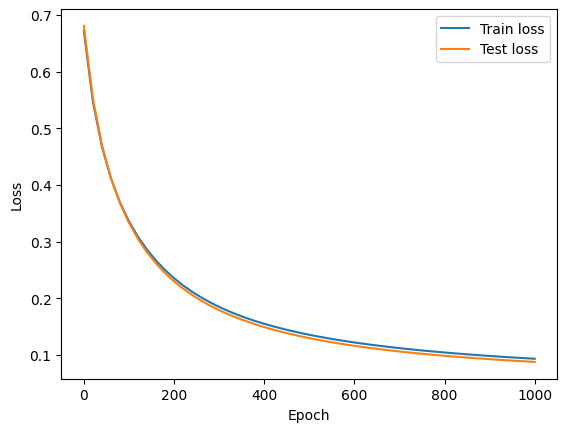

In [197]:
logs_array = np.array(logs)
plt.plot(logs_array[:, 0], logs_array[:, 1], label="Train loss")
plt.plot(logs_array[:, 0], logs_array[:, 2], label="Test loss")
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

## **Confusion Matrix**

0 → malignant (M)

1 → benign (B)

In [198]:
np.unique(y_test.cpu().numpy(), return_counts=True)

(array([0., 1.], dtype=float32), array([43, 71]))

In [199]:
cm = confusion_matrix(y_true=y_test.detach().cpu(), y_pred=y_preds_test_labels.detach().cpu())

Text(0.5, 1.0, 'Breast Cancer Confusion Matrix')

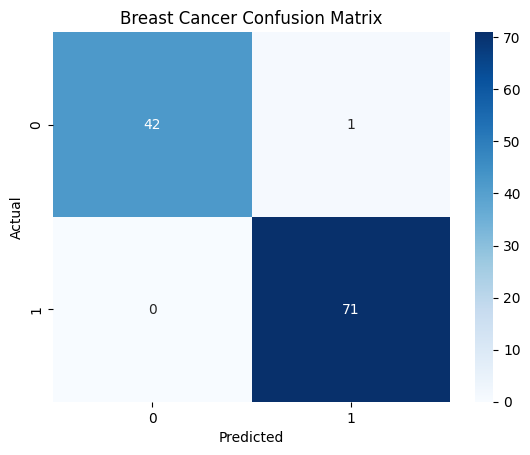

In [200]:
sns.heatmap(data=cm, annot=True, cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Breast Cancer Confusion Matrix")

## **Save and Load Model**

### Save

In [201]:
# All we need in one dictionary
model_dict = {
    "inputs": inputs_labels,
    "targets": target,
    "scalar_model": scalar_model,
    "nn_model": cancer_model.state_dict()
}

In [202]:
torch.save(model_dict, "breast_cancer_model_V0.pt")

### Load and Predict

In [203]:
model_dict_temp = torch.load("breast_cancer_model_V0.pt", weights_only=False)

In [204]:
# model_dict_temp

In [205]:
cancer_model_temp = CancerModelV0(len(model_dict_temp["inputs"]), len(model_dict_temp["targets"]))
cancer_model_temp

CancerModelV0(
  (layer0): Linear(in_features=19, out_features=32, bias=True)
  (layer1): Linear(in_features=32, out_features=1, bias=True)
)

In [206]:
cancer_model_temp.load_state_dict(model_dict_temp["nn_model"])

<All keys matched successfully>

In [207]:
with torch.inference_mode():
  # Going from raw model outputs to predicted labels (logits -> prediction probabilities -> prediction labels(round))
  y_preds_test = torch.round(torch.sigmoid(cancer_model(X_test)))

  print(classification_report(y_pred=y_preds_test.detach().cpu(), y_true=y_test.detach().cpu()))

              precision    recall  f1-score   support

         0.0       1.00      0.98      0.99        43
         1.0       0.99      1.00      0.99        71

    accuracy                           0.99       114
   macro avg       0.99      0.99      0.99       114
weighted avg       0.99      0.99      0.99       114



# *Circles*
Numerical Data

Binary Classification

## **Load Data**

In [208]:
X, y = make_circles(n_samples=1000, noise=0.025, random_state=RANDOM_SEED)

<Axes: >

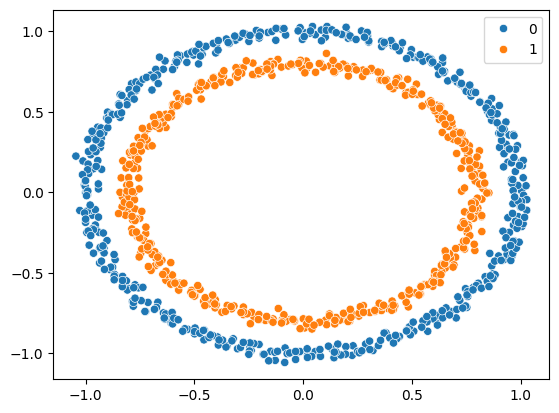

In [209]:
sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=y)

## **Convert to Tensor**

In [210]:
# torch.from_numpy
X = torch.from_numpy(X).type(torch.float32)
y = torch.from_numpy(y).type(torch.float32).unsqueeze(1)

X[:2], y[:2]

(tensor([[ 0.7573,  0.2277],
         [-0.7617,  0.1494]]),
 tensor([[1.],
         [1.]]))

## **Split Data**

In [211]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_SEED)

In [212]:
X_train.shape, y_train.shape

(torch.Size([800, 2]), torch.Size([800, 1]))

In [213]:
X_test.shape, y_test.shape

(torch.Size([200, 2]), torch.Size([200, 1]))

## **Set Device**

In [214]:
X_train = X_train.to(device)
X_test = X_test.to(device)
y_train = y_train.to(device)
y_test = y_test.to(device)

## **Build a Model**

In [215]:
class CircleModelV0(nn.Module):
  def __init__(self, input_size, output_size):
    super().__init__()

    self.layer0 = nn.Linear(in_features=input_size, out_features=5) # takes in 2 features (X), produces 5 features
    self.layer1 = nn.Linear(in_features=5, out_features=output_size) # takes in 5 features (X), produces 1 features (same shape as y)

  def forward(self, X: torch.tensor) -> torch.tensor:
    # computation goes through layer_1 first then the output of layer_1 goes through layer_2
    x = self.layer0(X)
    x = self.layer1(x)

    return x

In [216]:
torch.manual_seed(RANDOM_SEED)
torch.cuda.manual_seed(RANDOM_SEED)
torch.mps.manual_seed(RANDOM_SEED)

circle_model = CircleModelV0(len(X_train[0]), len(y_train[0])).to(device)

In [217]:
circle_model, next(circle_model.parameters()).device

(CircleModelV0(
   (layer0): Linear(in_features=2, out_features=5, bias=True)
   (layer1): Linear(in_features=5, out_features=1, bias=True)
 ),
 device(type='cpu'))

## **Setup loss function and optimizer**

For a binary classification problem, you'll often use binary cross entropy as the loss function.

<div class="md-typeset__table"><table>
<thead>
<tr>
<th>Loss function/Optimizer</th>
<th>Problem type</th>
<th>PyTorch Code</th>
</tr>
</thead>
<tbody>
<tr>
<td>Stochastic Gradient Descent (SGD) optimizer</td>
<td>Classification, regression, many others.</td>
<td><a href="https://pytorch.org/docs/stable/generated/torch.optim.SGD.html"><code>torch.optim.SGD()</code></a></td>
</tr>
<tr>
<td>Adam Optimizer</td>
<td>Classification, regression, many others.</td>
<td><a href="https://pytorch.org/docs/stable/generated/torch.optim.Adam.html"><code>torch.optim.Adam()</code></a></td>
</tr>
<tr>
<td>Binary cross entropy loss</td>
<td>Binary classification</td>
<td><a href="https://pytorch.org/docs/stable/generated/torch.nn.BCEWithLogitsLoss.html"><code>torch.nn.BCELossWithLogits</code></a> or <a href="https://pytorch.org/docs/stable/generated/torch.nn.BCELoss.html"><code>torch.nn.BCELoss</code></a></td>
</tr>
<tr>
<td>Cross entropy loss</td>
<td>Multi-class classification</td>
<td><a href="https://pytorch.org/docs/stable/generated/torch.nn.CrossEntropyLoss.html"><code>torch.nn.CrossEntropyLoss</code></a></td>
</tr>
<tr>
<td>Mean absolute error (MAE) or L1 Loss</td>
<td>Regression</td>
<td><a href="https://pytorch.org/docs/stable/generated/torch.nn.L1Loss.html"><code>torch.nn.L1Loss</code></a></td>
</tr>
<tr>
<td>Mean squared error (MSE) or L2 Loss</td>
<td>Regression</td>
<td><a href="https://pytorch.org/docs/stable/generated/torch.nn.MSELoss.html#torch.nn.MSELoss"><code>torch.nn.MSELoss</code></a></td>
</tr>
</tbody>
</table></div>

In [218]:
# Create a loss function
# loss_fn = nn.BCELoss() # BCELoss = no sigmoid built-in
loss_fn = nn.BCEWithLogitsLoss() # BCEWithLogitsLoss = sigmoid built-in

# Create an optimizer
optimizer = torch.optim.SGD(params=circle_model.parameters(), lr=0.01)

## **Train Model**


Our model outputs are going to be **raw logits**.

We can convert these **logits** into **prediction probabilities** by passing them to some kind of activation function (e.g. sigmoid for binary classification and softmax for multiclass classification).

Then we can convert our model's prediction probabilities to **prediction labels** by either rounding them or taking the argmax().

### Train Test

In [219]:
%%time
epochs = 1_001
logs = []

for epoch in range(epochs):
  ### Training
  circle_model.train()

  # 1. Forward pass
  y_logits = circle_model(X_train)

  # 2. Calculate loss/accuracy
  # loss = loss_fn(torch.sigmoid(y_logits), # nn.BCELoss expects prediction probabilities as input
  loss = loss_fn(y_logits, y_train)

  # 3. Optimizer zero grad
  optimizer.zero_grad()

  # 4. Loss backward (backpropagation)
  loss.backward()

  # 5. Optimizer step (gradient descent)
  optimizer.step()

  ### Testing
  circle_model.eval()

  with torch.inference_mode():
    # Going from raw model outputs to predicted labels (logits -> prediction probabilities -> prediction labels(round))
    y_preds_test_labels = torch.round(torch.sigmoid(circle_model(X_test)))

    test_loss = loss_fn(circle_model(X_test), y_test)

    if epoch % 50 == 0:
      logs.append([epoch, loss.detach().cpu().numpy(), test_loss.detach().cpu().numpy()])
      print(f"epoch: {epoch}, train loss: {loss}, test loss: {test_loss}")

epoch: 0, train loss: 0.6956833004951477, test loss: 0.6973860859870911
epoch: 50, train loss: 0.6946631073951721, test loss: 0.6966331601142883
epoch: 100, train loss: 0.694044828414917, test loss: 0.6962175965309143
epoch: 150, train loss: 0.6936694383621216, test loss: 0.695992648601532
epoch: 200, train loss: 0.6934406161308289, test loss: 0.6958727836608887
epoch: 250, train loss: 0.6933000683784485, test loss: 0.6958087086677551
epoch: 300, train loss: 0.6932128071784973, test loss: 0.6957724690437317
epoch: 350, train loss: 0.6931576728820801, test loss: 0.6957487463951111
epoch: 400, train loss: 0.6931219696998596, test loss: 0.6957293748855591
epoch: 450, train loss: 0.6930980682373047, test loss: 0.6957105398178101
epoch: 500, train loss: 0.6930814385414124, test loss: 0.6956903338432312
epoch: 550, train loss: 0.6930692791938782, test loss: 0.6956682801246643
epoch: 600, train loss: 0.6930599808692932, test loss: 0.6956443786621094
epoch: 650, train loss: 0.6930525302886963,

In [220]:
print(classification_report(y_pred=y_preds_test_labels.detach().cpu(), y_true=y_test.detach().cpu()))

              precision    recall  f1-score   support

         0.0       0.46      0.45      0.46       100
         1.0       0.47      0.48      0.47       100

    accuracy                           0.47       200
   macro avg       0.46      0.46      0.46       200
weighted avg       0.46      0.47      0.46       200



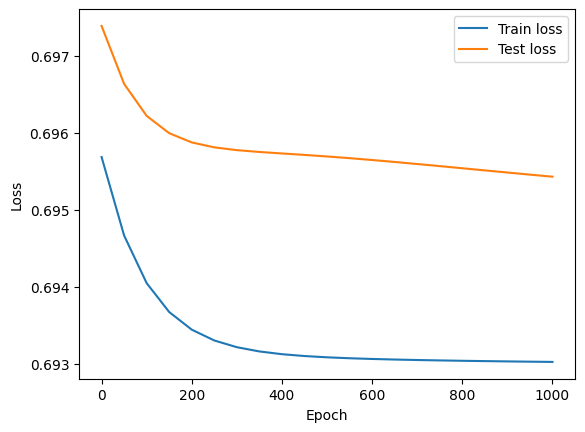

In [221]:
logs_array = np.array(logs)
plt.plot(logs_array[:, 0], logs_array[:, 1], label="Train loss")
plt.plot(logs_array[:, 0], logs_array[:, 2], label="Test loss")
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

### Visualize Model

Let's make a plot of our model's predictions, the data it's trying to predict on and the decision boundary it's creating for whether something is class 0 or class 1.

To do so, we used the helper_functions.py script from the Learn PyTorch for Deep Learning repo.

It contains a helpful function called plot_decision_boundary() which creates a NumPy meshgrid to visually plot the different points where our model is predicting certain classes.

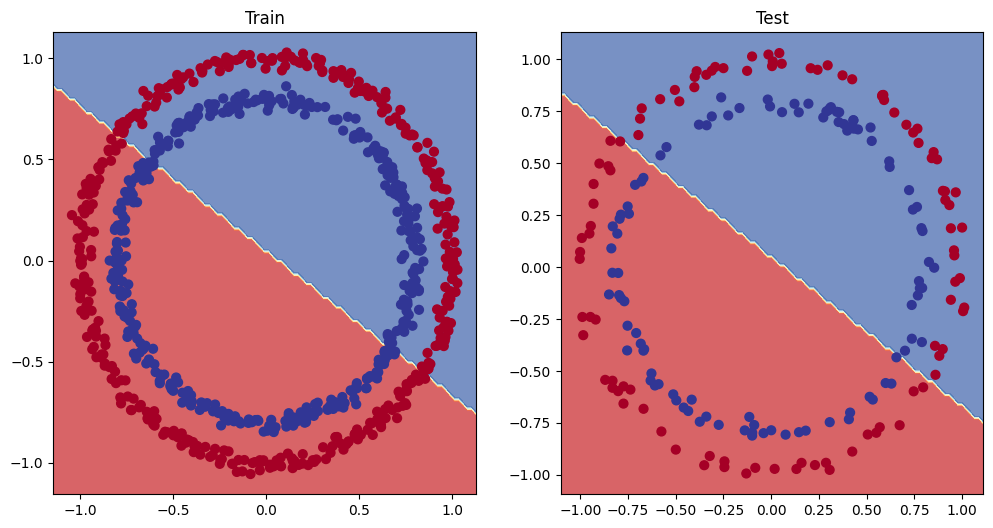

In [222]:
# Plot decision boundaries for training and test sets
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(circle_model, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(circle_model, X_test, y_test)

## **Improving a Model (from a model perspective)**

<div class="md-typeset__table"><table>
<thead>
<tr>
<th>Model improvement technique*</th>
<th>What does it do?</th>
</tr>
</thead>
<tbody>
<tr>
<td><strong>Add more layers</strong></td>
<td>Each layer <em>potentially</em> increases the learning capabilities of the model with each layer being able to learn some kind of new pattern in the data. More layers are often referred to as making your neural network <em>deeper</em>.</td>
</tr>
<tr>
<td><strong>Add more hidden units</strong></td>
<td>Similar to the above, more hidden units per layer means a <em>potential</em> increase in learning capabilities of the model. More hidden units are often referred to as making your neural network <em>wider</em>.</td>
</tr>
<tr>
<td><strong>Fitting for longer (more epochs)</strong></td>
<td>Your model might learn more if it had more opportunities to look at the data.</td>
</tr>
<tr>
<td><strong>Changing the activation functions</strong></td>
<td>Some data just can't be fit with only straight lines (like what we've seen), using non-linear activation functions can help with this (hint, hint).</td>
</tr>
<tr>
<td><strong>Change the learning rate</strong></td>
<td>Less model specific, but still related, the learning rate of the optimizer decides how much a model should change its parameters each step, too much and the model overcorrects, too little and it doesn't learn enough.</td>
</tr>
<tr>
<td><strong>Change the loss function</strong></td>
<td>Again, less model specific but still important, different problems require different loss functions. For example, a binary cross entropy loss function won't work with a multi-class classification problem.</td>
</tr>
<tr>
<td><strong>Use transfer learning</strong></td>
<td>Take a pretrained model from a problem domain similar to yours and adjust it to your own problem. We cover transfer learning in <a href="https://www.learnpytorch.io/06_pytorch_transfer_learning/">notebook 06</a>.</td>
</tr>
</tbody>
</table></div>

In [223]:
class CircleModelV1(nn.Module):
  def __init__(self, input_size, output_size):
    super().__init__()

    self.layer0 = nn.Linear(in_features=input_size, out_features=10)
    self.layer1 = nn.Linear(in_features=10, out_features=10)
    self.layer2 = nn.Linear(in_features=10, out_features=output_size)

  def forward(self, x: torch.tensor) -> torch.tensor:
    # Creating a model like this is the same as below, though below
    # generally benefits from speedups where possible.
    x = self.layer0(x)
    x = self.layer1(x)
    x = self.layer2(x)
    return x

    # return self.layer_3(self.layer_2(self.layer_1(x)))

circle_model_1 = CircleModelV1(len(X_train[0]), len(y_train[0])).to(device)

# Create a loss function
# loss_fn = nn.BCELoss() # BCELoss = no sigmoid built-in
loss_fn = nn.BCEWithLogitsLoss() # BCEWithLogitsLoss = sigmoid built-in

# Create an optimizer
optimizer = torch.optim.SGD(params=circle_model_1.parameters(), lr=0.01)

In [224]:
%%time
epochs = 1_001
logs = []

for epoch in range(epochs):
  ### Training
  circle_model_1.train()

  # 1. Forward pass
  y_logits = circle_model_1(X_train)

  # 2. Calculate loss/accuracy
  # loss = loss_fn(torch.sigmoid(y_logits), # nn.BCELoss expects prediction probabilities as input
  loss = loss_fn(y_logits, y_train)

  # 3. Optimizer zero grad
  optimizer.zero_grad()

  # 4. Loss backward (backpropagation)
  loss.backward()

  # 5. Optimizer step (gradient descent)
  optimizer.step()

  ### Testing
  circle_model_1.eval()

  with torch.inference_mode():
    # Going from raw model outputs to predicted labels (logits -> prediction probabilities -> prediction labels(round))
    y_preds_test_labels = torch.round(torch.sigmoid(circle_model_1(X_test)))

    test_loss = loss_fn(circle_model_1(X_test), y_test)

    if epoch % 50 == 0:
      logs.append([epoch, loss.detach().cpu().numpy(), test_loss.detach().cpu().numpy()])
      print(f"epoch: {epoch}, train loss: {loss}, test loss: {test_loss}")

epoch: 0, train loss: 0.7002241611480713, test loss: 0.7016198635101318
epoch: 50, train loss: 0.6979407668113708, test loss: 0.6992961168289185
epoch: 100, train loss: 0.6965544819831848, test loss: 0.6978880167007446
epoch: 150, train loss: 0.6956617832183838, test loss: 0.6969841718673706
epoch: 200, train loss: 0.6950544118881226, test loss: 0.6963721513748169
epoch: 250, train loss: 0.6946208477020264, test loss: 0.6959373950958252
epoch: 300, train loss: 0.6942986249923706, test loss: 0.6956162452697754
epoch: 350, train loss: 0.6940515041351318, test loss: 0.695371150970459
epoch: 400, train loss: 0.6938575506210327, test loss: 0.6951795816421509
epoch: 450, train loss: 0.693702757358551, test loss: 0.6950274109840393
epoch: 500, train loss: 0.6935775279998779, test loss: 0.6949048042297363
epoch: 550, train loss: 0.6934754848480225, test loss: 0.6948050856590271
epoch: 600, train loss: 0.693391740322113, test loss: 0.6947237253189087
epoch: 650, train loss: 0.6933227777481079, 

In [225]:
print(classification_report(y_pred=y_preds_test_labels.detach().cpu(), y_true=y_test.detach().cpu()))

              precision    recall  f1-score   support

         0.0       0.49      0.49      0.49       100
         1.0       0.49      0.49      0.49       100

    accuracy                           0.49       200
   macro avg       0.49      0.49      0.49       200
weighted avg       0.49      0.49      0.49       200



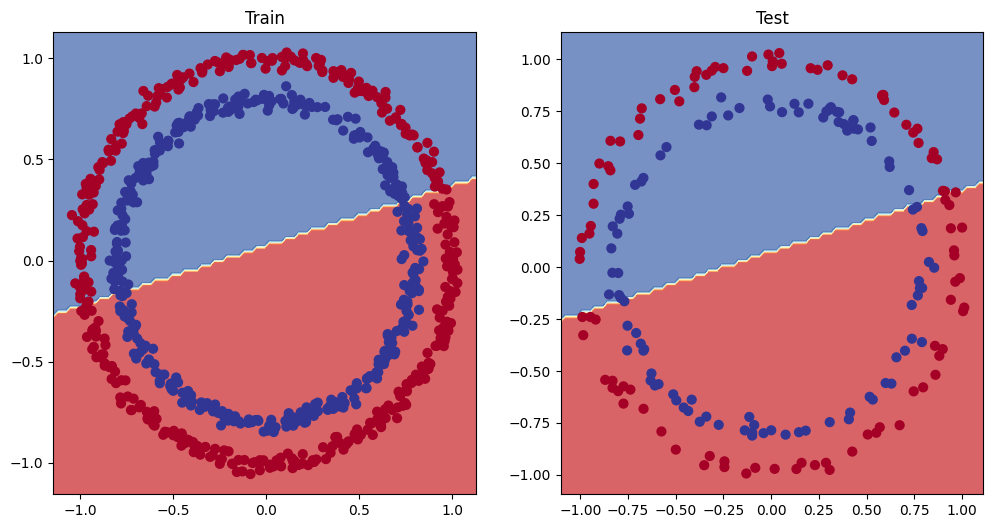

In [226]:
# Plot decision boundaries for training and test sets
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(circle_model_1, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(circle_model_1, X_test, y_test)

## **The missing piece: non-linearity**

### Visualize Train and Test Data

Text(0.5, 1.0, 'Test Data')

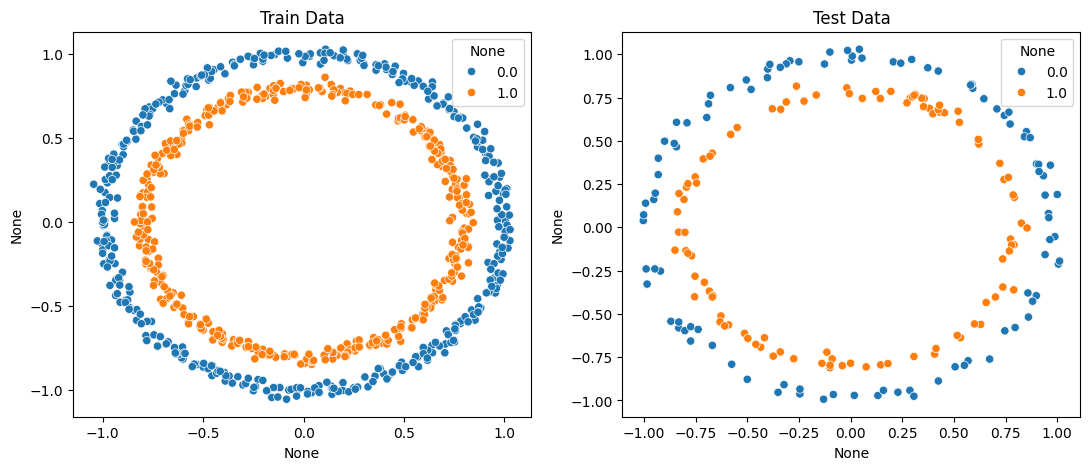

In [227]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.scatterplot(x=X_train[:, 0].detach().cpu(), y=X_train[:, 1].detach().cpu(), hue=y_train.squeeze().detach().cpu(), ax=axes[0])
sns.scatterplot(x=X_test[:, 0].detach().cpu(), y=X_test[:, 1].detach().cpu(), hue=y_test.squeeze().detach().cpu(), ax=axes[1])

axes[0].set_title("Train Data")
axes[1].set_title("Test Data")

### Build a Model

PyTorch has a bunch of ready-made non-linear activation functions that do similar but different things.

One of the most common and best performing is ReLU) (rectified linear-unit, torch.nn.ReLU()).

In [228]:
class CircleModelV2(nn.Module):
  def __init__(self):
    super().__init__()

    self.layer_1 = nn.Linear(in_features=2, out_features=8)
    self.layer_2 = nn.Linear(in_features=8, out_features=8)
    self.layer_3 = nn.Linear(in_features=8, out_features=1)
    self.relu = nn.ReLU() # <- add in ReLU activation function
    # Can also put sigmoid in the model


  def forward(self, x: torch.Tensor) -> torch.Tensor:
    x = self.layer_1(x)
    x = self.relu(x)
    x = self.layer_2(x)
    x = self.relu(x)
    x = self.layer_3(x)

    return x

### Train the Model

Binary cross entropy doesn’t just check if predictions are correct — it measures how **confident the model** is in the correct answer.

In [229]:
torch.manual_seed(RANDOM_SEED)
torch.cuda.manual_seed(RANDOM_SEED)
torch.mps.manual_seed(RANDOM_SEED)

circle_model_2 = CircleModelV2().to(device)
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(params=circle_model_2.parameters(), lr=0.1)

In [230]:
%%time
epochs = 2001
logs = []

for epoch in range(epochs):
  ### 0.Training
  circle_model_2.train()

  # Forward pass
  y_logits = circle_model_2(X_train)

  # Calculate the loss
  loss = loss_fn(y_logits, y_train)
  train_accu = accuracy_score(y_true=y_train.detach().cpu(), y_pred=torch.round(torch.sigmoid(y_logits.detach().cpu())))

  optimizer.zero_grad()

  loss.backward()

  optimizer.step()

  ### Testing
  circle_model_2.eval()

  with torch.inference_mode():
    y_logits_test = circle_model_2(X_test)                  # raw outputs
    loss_test = loss_fn(y_logits_test, y_test)              # loss on logits (or probs)
    y_pred_test = torch.round(torch.sigmoid(y_logits_test)) # hard predictions for metrics
    test_accu = accuracy_score(y_true=y_test.detach().cpu(), y_pred=y_pred_test.detach().cpu())

    if epoch % 100 == 0:
      logs.append([epoch, loss.detach().cpu().numpy(), loss_test.detach().cpu().numpy()])
      print(f"epoch: {epoch}\ntrain loss: {loss}, train accuracy: {train_accu}")
      print(f"test loss:  {loss_test}, test accuracy:  {test_accu}\n")

epoch: 0
train loss: 0.6926580667495728, train accuracy: 0.5
test loss:  0.6899540424346924, test accuracy:  0.5

epoch: 100
train loss: 0.6904250979423523, train accuracy: 0.50875
test loss:  0.687571108341217, test accuracy:  0.555

epoch: 200
train loss: 0.6888810992240906, train accuracy: 0.51625
test loss:  0.6855924129486084, test accuracy:  0.565

epoch: 300
train loss: 0.6868629455566406, train accuracy: 0.51875
test loss:  0.6830874681472778, test accuracy:  0.555

epoch: 400
train loss: 0.6840305924415588, train accuracy: 0.52625
test loss:  0.6797874569892883, test accuracy:  0.56

epoch: 500
train loss: 0.6797201633453369, train accuracy: 0.54125
test loss:  0.6751205325126648, test accuracy:  0.565

epoch: 600
train loss: 0.6726846098899841, train accuracy: 0.60125
test loss:  0.6679725646972656, test accuracy:  0.61

epoch: 700
train loss: 0.6610581278800964, train accuracy: 0.7175
test loss:  0.6572464108467102, test accuracy:  0.74

epoch: 800
train loss: 0.639786779880

Binary cross entropy doesn’t just check if predictions are correct — it measures how confident the model is in the correct answer.

If your model predicts 0.6 for a true label 1, it’s a correct classification after rounding (accuracy ↑), but BCE will still penalize it because 0.6 is far from 1.0.

The only way BCE would be 0.0 is if your model outputs exactly 1.0 for all positives and 0.0 for all negatives (or logits → ±∞), which basically never happens.

### Epoch & Loss Visualized

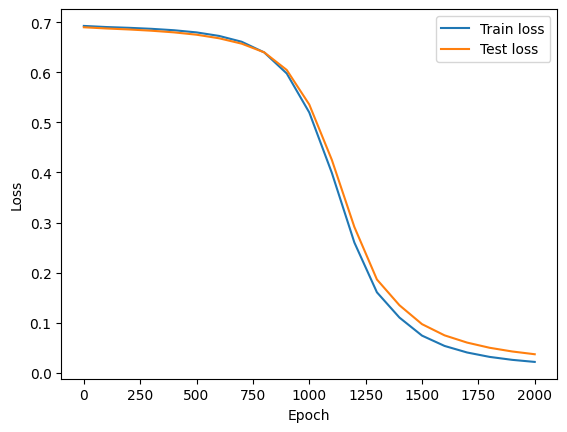

In [231]:
logs_array = np.array(logs)
plt.plot(logs_array[:, 0], logs_array[:, 1], label="Train loss")
plt.plot(logs_array[:, 0], logs_array[:, 2], label="Test loss")
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

### Evaluate the Model

In [232]:
y_pred_test = torch.round(torch.sigmoid(circle_model_2(X_test) )) # hard predictions for metrics

In [233]:
print(classification_report(y_pred=y_pred_test.detach().cpu(), y_true=y_test.detach().cpu()))

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00       100
         1.0       1.00      1.00      1.00       100

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



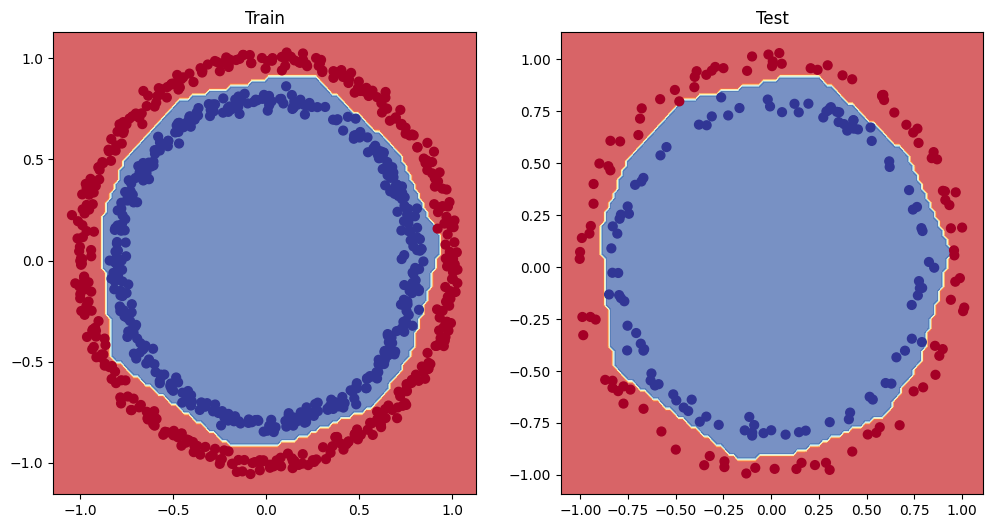

In [234]:
# Plot decision boundaries for training and test sets
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(circle_model_2, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(circle_model_2, X_test, y_test)

# Replicating non-linear activation functions

In [235]:
A = torch.arange(-10, 10, 1, dtype=torch.float32)
A

tensor([-10.,  -9.,  -8.,  -7.,  -6.,  -5.,  -4.,  -3.,  -2.,  -1.,   0.,   1.,
          2.,   3.,   4.,   5.,   6.,   7.,   8.,   9.])

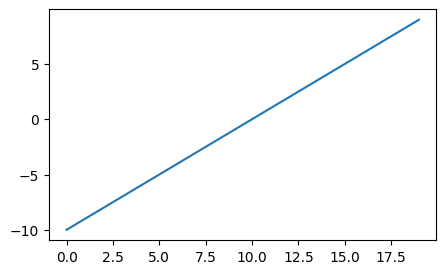

In [236]:
plt.figure(figsize=(5, 3))
plt.plot(A)

relu(x) = max(0, x)

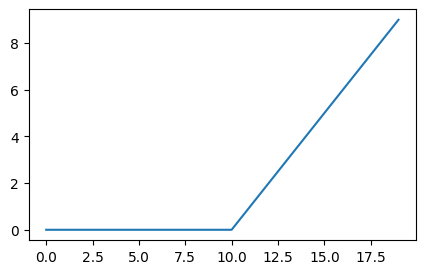

In [237]:
plt.figure(figsize=(5, 3))
plt.plot(torch.relu(A))

sigmoid(x) = $\frac{\text{1}}{\text{1 + e^-x}}$

`torch.exp`

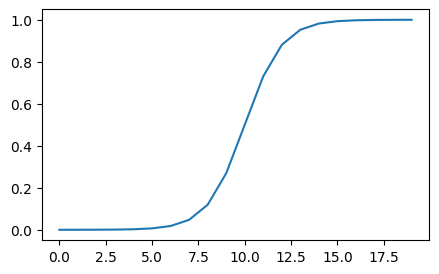

In [238]:
plt.figure(figsize=(5, 3))
plt.plot(torch.sigmoid(A))

<img src="https://www.gstatic.com/education/formulas2/553212783/en/softmax_function.svg">

tensor(1.0000)

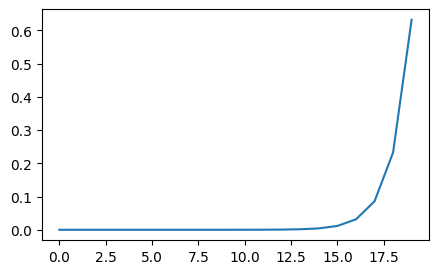

In [260]:
plt.figure(figsize=(5, 3))
plt.plot(torch.softmax(A, dim=0))
torch.sum(torch.softmax(A, dim=0))

# Blobs
Putting things together by building a multi-class PyTorch model

## **Create Data**

In [304]:
X, y = make_blobs(n_samples=1000,
                  centers=4,
                  random_state=RANDOM_SEED,
                  cluster_std=1.75)

<Axes: >

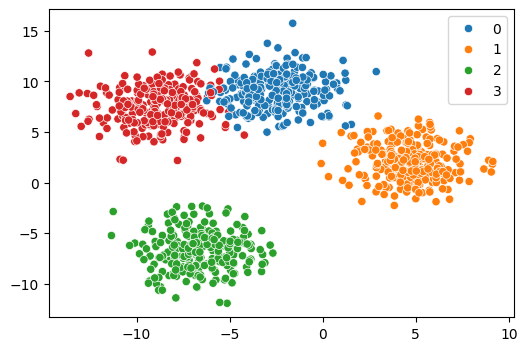

In [305]:
plt.figure(figsize=(6, 4))
sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=y, palette="tab10")

## **Split Data**

In [306]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_SEED)

In [307]:
X_train.shape, y_train.shape

((800, 2), (800,))

In [308]:
X_test.shape, y_test.shape

((200, 2), (200,))

## **Convert to Tensor & Set Device**

In [309]:
X_train, y_train = torch.from_numpy(X_train).type(torch.float32).to(device), torch.from_numpy(y_train).type(torch.LongTensor).to(device)
X_test, y_test = torch.from_numpy(X_test).type(torch.float32).to(device), torch.from_numpy(y_test).type(torch.LongTensor).to(device)

In [310]:
y_train[:5], y_test[:5]

(tensor([1, 0, 2, 2, 0]), tensor([1, 3, 2, 1, 0]))

## **Build a Model**

In [311]:
class BlobModelV0(nn.Module):
  def __init__(self):
    super().__init__()

    self.layer_1 = nn.Linear(in_features=2, out_features=8)
    self.layer_2 = nn.Linear(in_features=8, out_features=8)
    self.layer_3 = nn.Linear(in_features=8, out_features=4)
    self.relu = nn.ReLU()

  def forward(self, x: torch.tensor) -> torch.tensor:
    x = self.layer_1(x)
    # x = self.relu(x) This dataset work well with just linear layers but using non-linear layers is totally fine
    x = self.layer_2(x)
    # x = self.relu(x)
    x = self.layer_3(x)

    return x

## **Training**

In [312]:
torch.manual_seed(RANDOM_SEED)
torch.cuda.manual_seed(RANDOM_SEED)
torch.mps.manual_seed(RANDOM_SEED)

blob_model = BlobModelV0().to(device)

loss_fn = nn.CrossEntropyLoss()

optimizer = torch.optim.SGD(params=blob_model.parameters(), lr=0.01)

In [313]:
epochs = 1001
logs = []

for epoch in range(epochs):
  ### Training
  blob_model.train()

  y_logits = blob_model(X_train)
  y_pred = torch.softmax(y_logits, dim=1).argmax(dim=1)

  loss = loss_fn(y_logits, y_train)
  train_accu = accuracy_score(y_pred=y_pred.detach().cpu(), y_true=y_train.detach().cpu())

  optimizer.zero_grad()

  loss.backward()

  optimizer.step()

  # ### Testing
  blob_model.eval()
  with torch.inference_mode():
    y_logit_test = blob_model(X_test)
    y_pred_test = torch.softmax(y_logit_test, dim=1).argmax(dim=1)

    loss_test = loss_fn(y_logit_test, y_test)
    test_accu = accuracy_score(y_pred=y_pred_test.detach().cpu(), y_true=y_test.detach().cpu())

    if epoch % 50 == 0:
      logs.append([epoch, loss.detach().cpu().numpy(), loss_test.detach().cpu().numpy()])
      print(f"epoch: {epoch}")
      print(f"Train loss: {loss}, Train Accuracy: {train_accu}")
      print(f"Test loss: {loss_test}, Test Accuracy: {test_accu}")

epoch: 0
Train loss: 1.047276258468628, Train Accuracy: 0.64
Test loss: 0.9674572944641113, Test Accuracy: 0.695
epoch: 50
Train loss: 0.2837030589580536, Train Accuracy: 0.9775
Test loss: 0.27961266040802, Test Accuracy: 0.975
epoch: 100
Train loss: 0.17450088262557983, Train Accuracy: 0.98
Test loss: 0.16942739486694336, Test Accuracy: 0.985
epoch: 150
Train loss: 0.13080617785453796, Train Accuracy: 0.98
Test loss: 0.12402156740427017, Test Accuracy: 0.985
epoch: 200
Train loss: 0.10820101946592331, Train Accuracy: 0.9825
Test loss: 0.10017582774162292, Test Accuracy: 0.985
epoch: 250
Train loss: 0.09473396092653275, Train Accuracy: 0.9825
Test loss: 0.08582881093025208, Test Accuracy: 0.985
epoch: 300
Train loss: 0.0859435573220253, Train Accuracy: 0.9825
Test loss: 0.07639078050851822, Test Accuracy: 0.985
epoch: 350
Train loss: 0.07982785999774933, Train Accuracy: 0.9825
Test loss: 0.06977841258049011, Test Accuracy: 0.985
epoch: 400
Train loss: 0.0753687396645546, Train Accuracy

In [314]:
with torch.inference_mode():
  y_logit = blob_model(X_test)
  y_pred = torch.softmax(y_logit, dim=1).argmax(dim=1)
  print(classification_report(y_pred=y_pred.detach().cpu(), y_true=y_test.detach().cpu()))

              precision    recall  f1-score   support

           0       0.96      1.00      0.98        49
           1       1.00      0.98      0.99        41
           2       1.00      1.00      1.00        53
           3       1.00      0.98      0.99        57

    accuracy                           0.99       200
   macro avg       0.99      0.99      0.99       200
weighted avg       0.99      0.99      0.99       200



In [315]:
torch.softmax(y_logit, dim=1)[:5]

tensor([[3.1347e-03, 9.9687e-01, 1.9683e-11, 6.7085e-09],
        [7.4034e-03, 3.0641e-10, 5.7701e-04, 9.9202e-01],
        [1.3587e-11, 1.0561e-14, 9.9985e-01, 1.5236e-04],
        [3.8406e-03, 9.9616e-01, 4.1021e-07, 1.9152e-06],
        [9.8892e-01, 1.1063e-02, 1.1334e-10, 1.3107e-05]])

## **Visualize and Evaluate**

<div class="md-typeset__table"><table>
<thead>
<tr>
<th><strong>Metric name/Evaluation method</strong></th>
<th><strong>Defintion</strong></th>
<th><strong>Code</strong></th>
</tr>
</thead>
<tbody>
<tr>
<td>Accuracy</td>
<td>Out of 100 predictions, how many does your model get correct? E.g. 95% accuracy means it gets 95/100 predictions correct.</td>
<td><a href="https://torchmetrics.readthedocs.io/en/stable/classification/accuracy.html#id3"><code>torchmetrics.Accuracy()</code></a> or <a href="https://scikit-learn.org/stable/modules/generated/sklearn.metrics.accuracy_score.html"><code>sklearn.metrics.accuracy_score()</code></a></td>
</tr>
<tr>
<td>Precision</td>
<td>Proportion of true positives over total number of samples. Higher precision leads to less false positives (model predicts 1 when it should've been 0).</td>
<td><a href="https://torchmetrics.readthedocs.io/en/stable/classification/precision.html#id4"><code>torchmetrics.Precision()</code></a> or <a href="https://scikit-learn.org/stable/modules/generated/sklearn.metrics.precision_score.html"><code>sklearn.metrics.precision_score()</code></a></td>
</tr>
<tr>
<td>Recall</td>
<td>Proportion of true positives over total number of true positives and false negatives (model predicts 0 when it should've been 1). Higher recall leads to less false negatives.</td>
<td><a href="https://torchmetrics.readthedocs.io/en/stable/classification/recall.html#id5"><code>torchmetrics.Recall()</code></a> or <a href="https://scikit-learn.org/stable/modules/generated/sklearn.metrics.recall_score.html"><code>sklearn.metrics.recall_score()</code></a></td>
</tr>
<tr>
<td>F1-score</td>
<td>Combines precision and recall into one metric. 1 is best, 0 is worst.</td>
<td><a href="https://torchmetrics.readthedocs.io/en/stable/classification/f1_score.html#f1score"><code>torchmetrics.F1Score()</code></a> or <a href="https://scikit-learn.org/stable/modules/generated/sklearn.metrics.f1_score.html"><code>sklearn.metrics.f1_score()</code></a></td>
</tr>
<tr>
<td><a href="https://www.dataschool.io/simple-guide-to-confusion-matrix-terminology/">Confusion matrix</a></td>
<td>Compares the predicted values with the true values in a tabular way, if 100% correct, all values in the matrix will be top left to bottom right (diagnol line).</td>
<td><a href="https://torchmetrics.readthedocs.io/en/stable/classification/confusion_matrix.html#confusionmatrix"><code>torchmetrics.ConfusionMatrix</code></a> or <a href="https://scikit-learn.org/stable/modules/generated/sklearn.metrics.ConfusionMatrixDisplay.html#sklearn.metrics.ConfusionMatrixDisplay.from_predictions"><code>sklearn.metrics.plot_confusion_matrix()</code></a></td>
</tr>
<tr>
<td>Classification report</td>
<td>Collection of some of the main classification metrics such as precision, recall and f1-score.</td>
<td><a href="https://scikit-learn.org/stable/modules/generated/sklearn.metrics.classification_report.html"><code>sklearn.metrics.classification_report()</code></a></td>
</tr>
</tbody>
</table></div>

### Epoch Loss

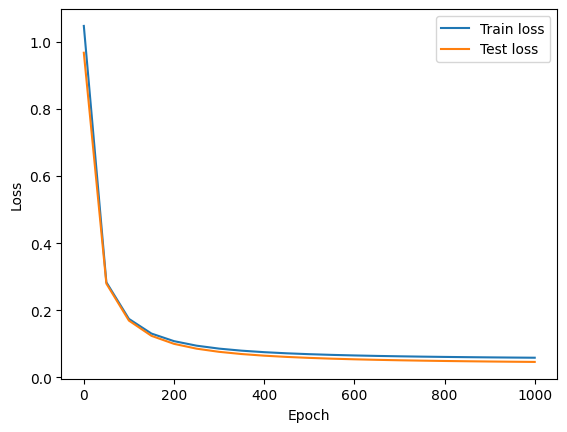

In [316]:
logs_array = np.array(logs)
plt.plot(logs_array[:, 0], logs_array[:, 1], label="Train loss")
plt.plot(logs_array[:, 0], logs_array[:, 2], label="Test loss")
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

### Confusion Matrix

In [317]:
np.unique_counts(y_test.detach().cpu().numpy())

UniqueCountsResult(values=array([0, 1, 2, 3]), counts=array([49, 41, 53, 57]))

<Axes: >

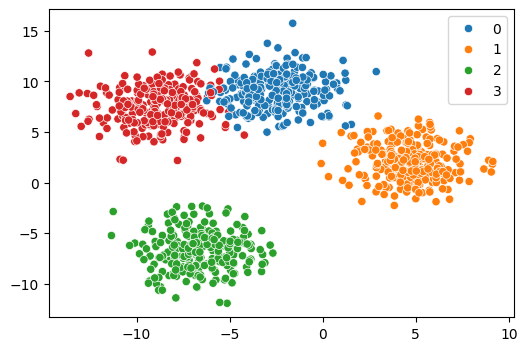

In [318]:
plt.figure(figsize=(6, 4))
sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=y, palette="tab10")

Text(0.5, 1.0, 'Breast Cancer Confusion Matrix')

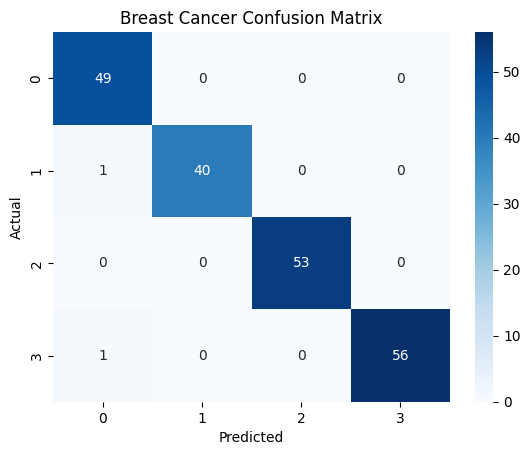

In [319]:
with torch.inference_mode():
  y_pred = torch.softmax(blob_model(X_test), dim=1).argmax(dim=1)
cm = confusion_matrix(y_true=y_test.detach().cpu().numpy(), y_pred=y_pred.detach().cpu().numpy())

sns.heatmap(data=cm, annot=True, cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Breast Cancer Confusion Matrix")

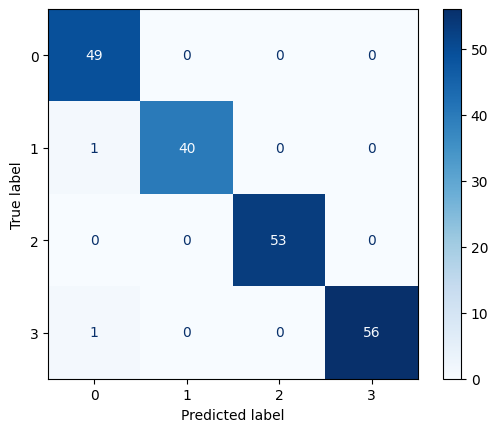

In [320]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_true=y_test.detach().cpu().numpy(),
    y_pred=y_pred.detach().cpu().numpy(),
    cmap="Blues"
)

### Decision Boundary

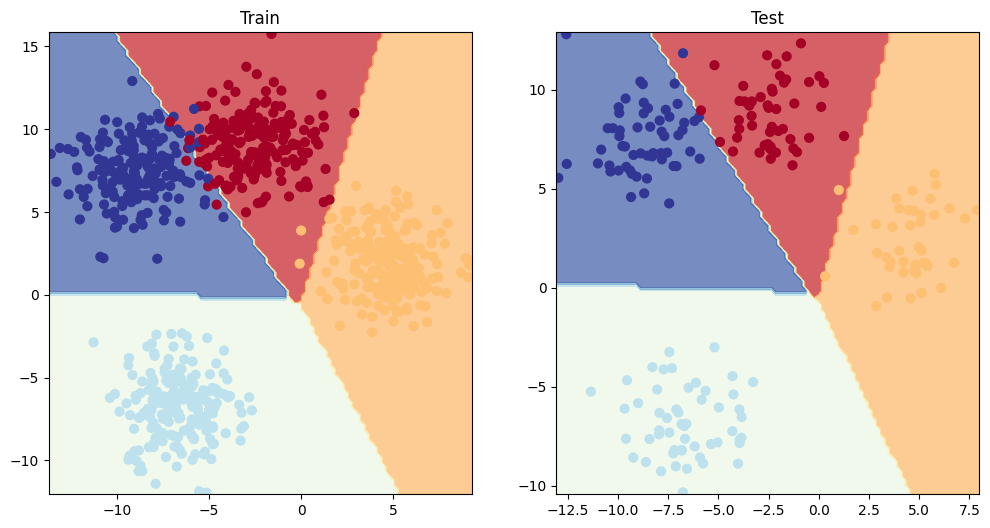

In [321]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(blob_model, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(blob_model, X_test, y_test)